In [21]:
import numpy as np
import pandas as pd
import geopandas as gpd
import umap.umap_ as umap
from boruta import BorutaPy
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import mutual_info_classif, chi2, RFE, SequentialFeatureSelector, VarianceThreshold, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1778700645.529652    2025 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778700668.769413    2025 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778700681.066132    2025 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [6]:
df_ch = pd.read_spss(r"/workspaces/malnutrition/Dataset/ch.sav")
df_ch.head(2)

,HH1,HH2,LN,UF1,UF2,UF3,UFINT,UF4,UF5,UF6,...,wscoreu,windex5u,windex10u,wscorer,windex5r,windex10r,ListCat,PSU,dstratum,stratum
0,1.0,3.0,5.0,1.0,3.0,5.0,103.0,4.0,103.0,100.0,...,NaN,NaN,NaN,-0.831559,Second,3rd decile,With child U5 during listing,1.0,"U5 HH, Province 1 Rural",Province 1 Rural
1,1.0,5.0,5.0,1.0,5.0,5.0,104.0,2.0,104.0,100.0,...,NaN,NaN,NaN,-1.220021,Poorest,2nd decile,With child U5 during listing,1.0,"U5 HH, Province 1 Rural",Province 1 Rural


In [7]:
# Rename columns
feature_coded = df_ch[['EC3A', 'EC3B', 'EC9', 'UCD2A', 'UCD2B', 'UCD2C', 'UCF4', 'BD2', 'BD3', 'IM2', 'cdisability', 'BD9', 'AN4', 'CA1', 'CA14', 'HH6', 'HL4', 
                       'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2', 'CA31', 'CA16']]

df1 = feature_coded.rename(columns={
    # Child supervision / discipline
    'EC3A': 'left alone',
    'EC3B': 'left with child',
    'EC9': 'can pick up',
    'UCD2A': 'away privileges',
    'UCD2B': 'behaviour explained',
    'UCD2C': 'shook',

    #Child mobility & disability
    'UCF4': 'walking assistance',
    'cdisability': 'child disability',

    # Feeding & nutrition practices
    'BD2': 'ever breastfed',
    'BD3': 'currently breastfed',
    'BD9': 'meal freqency',

    # Health & illness
    'IM2': 'vaccination card',
    'CA1': 'recent diarrhoea',
    'CA14': 'recent fever',
    'CA16': 'recent cough',

    # Demographics
    'AN4': 'child age',
    'HL4': 'child sex',

    # Household & socioeconomic
    'HH6': 'residence type',
    'HH7c': 'province',
    'melevel1': 'mother education',
    'cinsurance': 'health insurance',
    'CA31': 'stool disposal',
    'windex5': 'wealth index',

    # Target
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting', 
})

# Rename Provinces
province_map = {
    'Province 1': 'Koshi',
    'Province 2': 'Madhesh',
    'Province 5': 'Lumbini',
    'Bagmati Province': 'Bagmati',
    'Gandaki Province': 'Gandaki',
    'Karnali Province': 'Karnali',
    'Sudoorpaschim Province': 'Sudoorpaschim'
}

df1['province'] = df1['province'].str.strip()
df1['province'] = df1['province'].replace(province_map)


df = df1.copy()

# 1. Clean and create target variables FIRST
# Remove invalid/missing measurements
invalid_values = ['Z-score out of range', 'Not measured', 'Measurement out of range', 
                  ' Measurement out of range', 'DK', 'NO RESPONSE', 'Missing/DK']

df = df[~df['underweight'].isin(invalid_values)]
df = df[~df['stunting'].isin(invalid_values)]
df = df[~df['wasting'].isin(invalid_values)]

# Convert to numeric
df['underweight'] = pd.to_numeric(df['underweight'], errors='coerce')
df['stunting'] = pd.to_numeric(df['stunting'], errors='coerce')
df['wasting'] = pd.to_numeric(df['wasting'], errors='coerce')

# Drop any remaining NaN in target variables
df = df.dropna(subset=['underweight', 'stunting', 'wasting'])

# 2. Create binary indicators
df['underweight_binary'] = (df['underweight'] < -2).astype(int)
df['stunting_binary'] = (df['stunting'] < -2).astype(int)
df['wasting_binary'] = (df['wasting'] < -2).astype(int)

# Display prevalence rates
for col in ['underweight_binary', 'stunting_binary', 'wasting_binary']:
    print(f"{col}: {df[col].mean() * 100:.2f}%")


underweight_binary: 23.69%
stunting_binary: 32.37%
wasting_binary: 11.89%


Identify extreme values in z-scores

In [8]:
# Detailed extreme value analysis
for col in ['underweight', 'stunting', 'wasting']:
    below = (df[col] < -6).sum()
    above = (df[col] > 6).sum()
    print(f"\n{col}:")
    print(f"  < -6 SD: {below}")
    print(f"  > +6 SD: {above}")
    print(f"  Total extreme: {below + above}")
    print(f"  Min: {df[col].min():.2f}, Max: {df[col].max():.2f}")


underweight:
  < -6 SD: 0
  > +6 SD: 0
  Total extreme: 0
  Min: -5.62, Max: 4.47

stunting:
  < -6 SD: 0
  > +6 SD: 0
  Total extreme: 0
  Min: -5.98, Max: 5.86

wasting:
  < -6 SD: 0
  > +6 SD: 0
  Total extreme: 0
  Min: -5.00, Max: 5.00


In [9]:
# 3. Create composite malnutrition target (if any indicator is positive)
df['malnutrition'] = ((df['underweight_binary'] == 1) | 
                      (df['stunting_binary'] == 1) | 
                      (df['wasting_binary'] == 1)).astype(int)

# 4. Drop the z-scores and individual binary indicators (CRITICAL - prevent data leakage)
# Keep only the composite target
df = df.drop(['underweight', 'stunting', 'wasting', 
              'underweight_binary', 'stunting_binary', 'wasting_binary'], axis=1)

# 5. Handle missing values in features
# Convert categorical to object
for col in df.columns:
    if col != 'malnutrition' and df[col].dtype.name == 'category':
        df[col] = df[col].astype('object')

# Replace specific missing indicators
replace_dict = {
    'DK': 'Not asked',
    'NO RESPONSE': 'Not asked',
    'Missing/DK': 'Not asked',
    'NONE': '0'  # Keep as string for consistency
}
df = df.replace(replace_dict)

# Fill remaining NaN
df = df.fillna('Not asked')

print(f"Final dataset shape: {df.shape}")
print(f"Target distribution:\n{df['malnutrition'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum().sum()}")

Final dataset shape: (6416, 24)
Target distribution:
malnutrition
0    3671
1    2745
Name: count, dtype: int64

Missing values:
0


We selected explanatory variables spanning child demographics, health and morbidity, feeding and caregiving practices, maternal characteristics, and household socioeconomic and environmental conditions. These variables were chosen based on prior empirical research identifying key determinants of child malnutrition, as well as their availability in the Multiple Indicator Cluster Surveys (MICS) dataset. The selected features reflect established pathways through which biological, behavioral, and contextual factors influence nutritional outcomes in early childhood.

In [10]:
# Value counts for each column
for col in df.columns:
    print(f"="*20)
    print(df[col].value_counts())

left alone
0            5020
7.0           526
2.0           253
1.0           155
3.0           136
4.0           116
5.0           111
6.0            57
Not asked      42
Name: count, dtype: int64
left with child
0            5302
7.0           269
2.0           256
1.0           203
3.0           133
5.0           104
4.0            76
Not asked      39
6.0            34
Name: count, dtype: int64
can pick up
Not asked    3587
YES          2665
NO            164
Name: count, dtype: int64
away privileges
NO           3292
YES          2071
Not asked    1053
Name: count, dtype: int64
behaviour explained
YES          4229
NO           1141
Not asked    1046
Name: count, dtype: int64
shook
NO           3453
YES          1916
Not asked    1047
Name: count, dtype: int64
walking assistance
NO           3919
Not asked    2315
YES           182
Name: count, dtype: int64
ever breastfed
YES          3316
Not asked    2844
NO            256
Name: count, dtype: int64
currently breastfed
Not asked

## Encode 

In [11]:
def encode_all_features_keep_not_asked(df):
    """
    Encoding pipeline:
    - 'Not asked' → -1 for behavioral/ternary variables (age-dependent questions)
    - 'Not asked' → imputed for variables with very few "Not asked" (<1%)
    - Ordinal variables encoded with natural ordering
    """
    df = df.copy()
    
    # 1. ORDINAL ENCODING
    wealth_order = {'Poorest': 1, 'Second': 2, 'Middle': 3, 'Fourth': 4, 'Richest': 5}
    df['wealth index'] = df['wealth index'].map(wealth_order)
    
    # Mother education: only 3 "Not asked" (0.05%) - safe to impute
    education_order = {
        'None': 0, 
        'Basic (Gr 1-8)': 1, 
        'Secondary (Gr 9-12)': 2, 
        'Higher': 3, 
        'Not asked': np.nan
    }
    df['mother education'] = df['mother education'].map(education_order)
    edu_mode = df['mother education'].mode().iloc[0]
    df['mother education'] = df['mother education'].fillna(edu_mode)
    
    df['child age'] = pd.to_numeric(df['child age'], errors='coerce')
    
    # Meal frequency: high "Not asked" (64%) - keep as -1
    df['meal freqency'] = df['meal freqency'].replace({'7+': 7, 'Not asked': -1})
    df['meal freqency'] = pd.to_numeric(df['meal freqency'], errors='coerce')
    
    # 2. TERNARY ENCODING (YES/NO/NOT ASKED)
    # Use -1 for age-dependent questions (high "Not asked")
    # Use np.nan for questions with very low "Not asked" that we'll impute
    ternary_columns = {
        # Age-dependent (high "Not asked") → use -1
        'can pick up': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'away privileges': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'behaviour explained': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'shook': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'walking assistance': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'ever breastfed': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'currently breastfed': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'child disability': {'Has functional difficulty': 1, 'Has no functional difficulty': 0, 'Not asked': -1},
        
        # Very low "Not asked" (<1%) → use np.nan and impute
        'recent diarrhoea': {'YES': 1, 'NO': 0, 'Not asked': np.nan},
        'recent fever': {'YES': 1, 'NO': 0, 'Not asked': np.nan},
        'recent cough': {'YES': 1, 'NO': 0, 'Not asked': np.nan},
        'health insurance': {'With insurance': 1, 'Without insurance': 0, 'Not asked': np.nan}
    }
    
    for col, mapping in ternary_columns.items():
        df[col] = df[col].map(mapping)
    
    # Impute the few NaN values (for variables with <1% "Not asked")
    for col in ['recent diarrhoea', 'recent fever', 'recent cough', 'health insurance']:
        if df[col].isnull().any():
            mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 0
            df[col] = df[col].fillna(mode_val)
    
    # 3. BINARY ENCODING (no "Not asked")
    binary_only = {
        'residence type': {'URBAN': 1, 'RURAL': 0},
        'child sex': {'MALE': 1, 'FEMALE': 0}
    }
    
    for col, mapping in binary_only.items():
        df[col] = df[col].map(mapping)
    
    # 4. NUMERIC/COUNT VARIABLES (use -1 for "Not asked")
    df['left alone'] = pd.to_numeric(df['left alone'].replace('Not asked', -1), errors='coerce')
    df['left with child'] = pd.to_numeric(df['left with child'].replace('Not asked', -1), errors='coerce')
    
    # 5. BINARY CONVERSION for stool disposal and vaccination
    safe_disposal = [
        'PUT / RINSED INTO: TOILET OR LATRINE',
        'CHILD USED TOILET / LATRINE',
        'BURIED'
    ]
    unsafe_disposal = [
        'LEFT IN THE OPEN',
        'THROWN INTO GARBAGE (SOLID WASTE)',
        'PUT / RINSED INTO: DRAIN OR DITCH',
        'OTHER'
    ]
    
    df['safe stool disposal'] = df['stool disposal'].apply(
        lambda x: 1 if x in safe_disposal else (0 if x in unsafe_disposal else -1)
    )
    df = df.drop('stool disposal', axis=1)
    
    df['vaccination record'] = df['vaccination card'].apply(
        lambda x: 1 if x in ['YES, HAS ONLY CARD(S)', 
                              'YES, HAS CARD(S) AND OTHER DOCUMENT',
                              'YES, HAS ONLY OTHER DOCUMENT'] 
                  else (0 if x == 'NO, HAS NO CARDS AND NO OTHER DOCUMENT' else -1)
    )
    df = df.drop('vaccination card', axis=1)
    
    # 6. ONE-HOT ENCODE PROVINCE
    df = pd.get_dummies(df, columns=['province'], dtype=int)
    df = df.drop(columns=['province_Bagmati'])     # Drop 'province_Bagmati'
    df = df.rename(columns=lambda c: c.replace('province_', ''))
    
    print("="*60)
    print("ENCODING COMPLETE")
    print("="*60)
    print(f"Shape: {df.shape}")
    print(f"\nEncoding scheme:")
    print("  • Age-dependent variables: 1/0/-1 (YES/NO/Not asked)")
    print("  • Low-missingness variables: 1/0 (imputed)")
    print("  • Ordinal variables: Natural order")
    print("  • Province: One-hot encoded")
    
    return df

# Apply encoding
df_encoded = encode_all_features_keep_not_asked(df)

# Verify - NO dropna() needed!
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)
print(f"Missing values: {df_encoded.isnull().sum().sum()}")
print(f"Shape: {df_encoded.shape}")

# If there are still any NaN (shouldn't be), show which columns
if df_encoded.isnull().sum().sum() > 0:
    print("\n Remaining missing values:")
    print(df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0])
else:
    print("\n No missing values")

# Check distribution of -1 values (Not asked)
print("\n" + "="*60)
print("'NOT ASKED' (-1) DISTRIBUTION")
print("="*60)
not_asked_summary = []
for col in df_encoded.columns:
    if col.startswith('province') or col == 'malnutrition':
        continue
    if df_encoded[col].dtype in ['float64', 'int64']:
        n_not_asked = (df_encoded[col] == -1).sum()
        if n_not_asked > 0:
            pct = n_not_asked / len(df_encoded) * 100
            not_asked_summary.append({
                'Feature': col,
                'Count': n_not_asked,
                'Percentage': pct
            })

if not_asked_summary:
    import pandas as pd
    summary_df = pd.DataFrame(not_asked_summary).sort_values('Percentage', ascending=False)
    print(summary_df.to_string(index=False))
else:
    print("No features with -1 values")

ENCODING COMPLETE
Shape: (6416, 29)

Encoding scheme:
  • Age-dependent variables: 1/0/-1 (YES/NO/Not asked)
  • Low-missingness variables: 1/0 (imputed)
  • Ordinal variables: Natural order
  • Province: One-hot encoded

VERIFICATION
Missing values: 0
Shape: (6416, 29)

 No missing values

'NOT ASKED' (-1) DISTRIBUTION
            Feature  Count  Percentage
      meal freqency   4117   64.167706
        can pick up   3587   55.907107
currently breastfed   3100   48.316708
 vaccination record   2847   44.373441
safe stool disposal   2846   44.357855
     ever breastfed   2844   44.326683
 walking assistance   2315   36.081671
   child disability   2314   36.066085
    away privileges   1053   16.412095
              shook   1047   16.318579
behaviour explained   1046   16.302993
         left alone     42    0.654613
    left with child     39    0.607855


### UNDERSTAND WHY DATA IS MISSING (Most Important!)
Missing data is NOT random - it's systematic based on child age:

- Breastfeeding questions → Only asked for children 0-2 years → introduced a category "Not asked"
- "Can pick up" questions → Only for younger children → introduced a category "Not asked"
- Meal frequency → Age-dependent → introduced a category "Not asked"
- Vaccination/stool disposal → Only for certain age groups → introduced a category "Not asked"


For age-dependent variables, 'Not asked' responses were encoded as -1, distinguishing them from 'No' (0) and 'Yes' (1). This encoding preserves the informative pattern that certain questions were only applicable to specific age groups, allowing models to learn age-specific risk factors.

In [12]:
# df_final.to_csv("df_final.csv", index=False)

In [13]:
# ============================================
# PREPARE DATA
# ============================================

# Final dataset ready for modeling
df_final = df_encoded.copy()
X = df_final.drop('malnutrition', axis=1)
y = df_final['malnutrition']

print("\n" + "="*60)
print("READY FOR MODELING")
print("="*60)
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("="*60)
print("DATASET INFO")
print("="*60)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Total features: {X.shape[1]}")
print(f"Class distribution (original): {y.value_counts(normalize=True).round(3).to_dict()}")
print(f"Class distribution (after SMOTE): {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}")

# ============================================
# METHOD 1: FILTER METHODS (Fast, Model-agnostic)
# ============================================

print("\n" + "="*60)
print("METHOD 1: FILTER METHODS")
print("="*60)

# Initialize results dataframe
feature_scores = pd.DataFrame({'Feature': X.columns})

# 1A. MUTUAL INFORMATION (Best for capturing non-linear relationships)
print("\n[1/5] Mutual Information...")
mi_scores = mutual_info_classif(X_train, y_train, random_state=42, n_neighbors=3)
feature_scores['MI_Score'] = mi_scores
feature_scores['MI_Rank'] = feature_scores['MI_Score'].rank(ascending=False)

# 1B. CHI-SQUARE (Good for categorical/binary features)
print("[2/5] Chi-Square Test...")
# Chi2 requires non-negative features
X_train_nonneg = X_train - X_train.min() + 1e-10
chi2_scores, chi2_pvalues = chi2(X_train_nonneg, y_train)
feature_scores['Chi2_Score'] = chi2_scores
feature_scores['Chi2_PValue'] = chi2_pvalues
feature_scores['Chi2_Rank'] = feature_scores['Chi2_Score'].rank(ascending=False)

# 1C. VARIANCE THRESHOLD (Remove low-variance features)
print("[3/5] Variance Analysis...")
var_threshold = VarianceThreshold(threshold=0.01)
var_threshold.fit(X_train)
feature_scores['Variance'] = X_train.var().values
feature_scores['Low_Variance'] = ~var_threshold.get_support()

# 1D. CORRELATION WITH TARGET (For quick insights)
print("[4/5] Correlation with Target...")
correlations = []
for col in X_train.columns:
    corr = np.corrcoef(X_train[col], y_train)[0, 1]
    correlations.append(abs(corr))
feature_scores['Abs_Correlation'] = correlations
feature_scores['Corr_Rank'] = feature_scores['Abs_Correlation'].rank(ascending=False)

# 1E. ANOVA F-statistic (Classic statistical test)
print("[5/5] ANOVA F-Test...")
f_scores, f_pvalues = f_classif(X_train, y_train)
feature_scores['F_Score'] = f_scores
feature_scores['F_PValue'] = f_pvalues
feature_scores['F_Rank'] = feature_scores['F_Score'].rank(ascending=False)

print("\n✓ Filter methods complete")

# ============================================
# METHOD 2: WRAPPER METHODS (Slower, Model-specific)
# ============================================

print("\n" + "="*60)
print("METHOD 2: WRAPPER METHODS")
print("="*60)

# Scale features for wrapper methods
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2A. RECURSIVE FEATURE ELIMINATION (RFE) with Logistic Regression
print("\n[1/3] RFE with Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe_lr = RFE(estimator=lr, n_features_to_select=20, step=1)
rfe_lr.fit(X_train_scaled, y_train)
feature_scores['RFE_LR_Selected'] = rfe_lr.support_
feature_scores['RFE_LR_Rank'] = rfe_lr.ranking_

# 2B. RECURSIVE FEATURE ELIMINATION with Gradient Boosting
print("[2/3] RFE with Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
rfe_gb = RFE(estimator=gb, n_features_to_select=20, step=1)
rfe_gb.fit(X_train_scaled, y_train)
feature_scores['RFE_GB_Selected'] = rfe_gb.support_
feature_scores['RFE_GB_Rank'] = rfe_gb.ranking_

# 2C. SEQUENTIAL FEATURE SELECTION (Forward selection)
print("[3/3] Sequential Forward Selection...")
sfs = SequentialFeatureSelector(
    lr, 
    n_features_to_select=20, 
    direction='forward',
    scoring='f1',
    cv=3,
    n_jobs=-1
)
sfs.fit(X_train_scaled, y_train)
feature_scores['SFS_Selected'] = sfs.support_

print("\n✓ Wrapper methods complete")

# ============================================
# METHOD 3: EMBEDDED METHODS (Model-based importance)
# ============================================

print("\n" + "="*60)
print("METHOD 3: EMBEDDED METHODS")
print("="*60)

# 3A. RANDOM FOREST FEATURE IMPORTANCE
print("\n[1/4] Random Forest Importance...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
feature_scores['RF_Importance'] = rf.feature_importances_
feature_scores['RF_Rank'] = feature_scores['RF_Importance'].rank(ascending=False)

# 3B. GRADIENT BOOSTING FEATURE IMPORTANCE
print("[2/4] Gradient Boosting Importance...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
feature_scores['GB_Importance'] = gb.feature_importances_
feature_scores['GB_Rank'] = feature_scores['GB_Importance'].rank(ascending=False)

# 3C. LOGISTIC REGRESSION COEFFICIENTS (L1-regularized for sparsity)
print("[3/4] Logistic Regression (L1) Coefficients...")
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
lr_l1.fit(X_train_scaled, y_train)
feature_scores['LR_L1_Coef'] = np.abs(lr_l1.coef_[0])
feature_scores['LR_L1_Rank'] = feature_scores['LR_L1_Coef'].rank(ascending=False)

# 3D. XGBOOST IMPORTANCE (if available)
print("[4/4] XGBoost Importance...")
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
    xgb.fit(X_train_scaled, y_train)
    feature_scores['XGB_Importance'] = xgb.feature_importances_
    feature_scores['XGB_Rank'] = feature_scores['XGB_Importance'].rank(ascending=False)
except ImportError:
    print("  ⚠ XGBoost not available, skipping...")
    feature_scores['XGB_Importance'] = 0
    feature_scores['XGB_Rank'] = len(X.columns)

print("\n✓ Embedded methods complete")

# ============================================
# METHOD 4: BORUTA ALGORITHM
# ============================================

print("\n" + "="*60)
print("METHOD 4: BORUTA ALGORITHM")
print("="*60)

print("\nRunning Boruta feature selection (this may take a few minutes)...")

# Define Random Forest for Boruta
rf_boruta = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    max_depth=5,
    random_state=42
)

# Initialize Boruta
boruta_selector = BorutaPy(
    estimator=rf_boruta,
    n_estimators='auto',
    max_iter=100,
    alpha=0.05,
    verbose=0,  # Set to 2 for progress details
    random_state=42
)

# Fit Boruta on non-scaled data (Boruta works better with original scale for trees)
boruta_selector.fit(X_train.values, y_train.values)

# Extract Boruta results
boruta_support = boruta_selector.support_
boruta_support_weak = boruta_selector.support_weak_
boruta_ranking = boruta_selector.ranking_

# Add Boruta results to feature_scores
feature_scores['Boruta_Selected'] = boruta_support
feature_scores['Boruta_Tentative'] = boruta_support_weak
feature_scores['Boruta_Rank'] = boruta_ranking

# Create Boruta status
feature_scores['Boruta_Status'] = feature_scores.apply(
    lambda row: 'Confirmed' if row['Boruta_Selected'] 
                else ('Tentative' if row['Boruta_Tentative'] 
                      else 'Rejected'), 
    axis=1
)

# Count Boruta results
confirmed_count = feature_scores['Boruta_Status'].value_counts().get('Confirmed', 0)
tentative_count = feature_scores['Boruta_Status'].value_counts().get('Tentative', 0)
rejected_count = feature_scores['Boruta_Status'].value_counts().get('Rejected', 0)

print(f"\n✓ Boruta complete!")
print(f"  • Confirmed: {confirmed_count}")
print(f"  • Tentative: {tentative_count}")
print(f"  • Rejected: {rejected_count}")

# ============================================
# AGGREGATE RANKINGS
# ============================================

print("\n" + "="*60)
print("AGGREGATING ALL METHODS")
print("="*60)

# Calculate average rank across all ranking methods (including Boruta)
rank_columns = [col for col in feature_scores.columns if col.endswith('_Rank')]
feature_scores['Average_Rank'] = feature_scores[rank_columns].mean(axis=1)
feature_scores['Median_Rank'] = feature_scores[rank_columns].median(axis=1)

# Count how many methods selected this feature in top 20
feature_scores['Top20_Count'] = 0
for col in rank_columns:
    feature_scores['Top20_Count'] += (feature_scores[col] <= 20).astype(int)

# Add bonus for Boruta confirmed features
feature_scores['Boruta_Bonus'] = (feature_scores['Boruta_Status'] == 'Confirmed').astype(int)

# Create a combined score: lower average rank + Boruta confirmation
# Subtract 5 from average rank if Boruta confirmed (makes it more favorable)
feature_scores['Combined_Score'] = feature_scores['Average_Rank'] - (feature_scores['Boruta_Bonus'] * 5)

# Sort by combined score (considers both ensemble ranking and Boruta)
feature_scores_sorted = feature_scores.sort_values('Combined_Score')

# ============================================
# DISPLAY RESULTS
# ============================================

print("\n" + "="*60)
print("TOP 20 FEATURES (BY COMBINED SCORE)")
print("="*60)

display_cols = ['Feature', 'Average_Rank', 'Boruta_Status', 'Top20_Count', 
                'MI_Score', 'GB_Importance', 'RF_Importance']
print(feature_scores_sorted[display_cols].head(20).to_string(index=False))

# Show Boruta confirmed features
print("\n" + "="*60)
print("BORUTA CONFIRMED FEATURES")
print("="*60)
boruta_confirmed = feature_scores_sorted[feature_scores_sorted['Boruta_Status'] == 'Confirmed']
if len(boruta_confirmed) > 0:
    print(boruta_confirmed[['Feature', 'Average_Rank', 'Boruta_Rank']].to_string(index=False))
else:
    print("No features confirmed by Boruta")

# ============================================
# SAVE RESULTS
# ============================================

feature_scores_sorted.to_csv('feature_selection_comprehensive_with_boruta.csv', index=False)
print("\n✓ Results saved to 'feature_selection_comprehensive_with_boruta.csv'")

# ============================================
# METHOD 5: PERFORMANCE-BASED SELECTION
# ============================================

print("\n" + "="*60)
print("METHOD 5: PERFORMANCE-BASED SELECTION")
print("="*60)

# Test different feature selection strategies
performance_results = []

print("\nTesting different feature subset sizes...")

# Strategy 1: Top K by combined score
k_values = [5, 10, 15, 20, 25, 30]
for k in k_values:
    top_k_features = feature_scores_sorted.head(k)['Feature'].tolist()
    
    X_train_k = X_train[top_k_features]
    X_test_k = X_test[top_k_features]
    
    scaler_k = StandardScaler()
    X_train_k_scaled = scaler_k.fit_transform(X_train_k)
    X_test_k_scaled = scaler_k.transform(X_test_k)
    
    gb_k = GradientBoostingClassifier(n_estimators=100, random_state=42)
    cv_scores = cross_val_score(gb_k, X_train_k_scaled, y_train, 
                                 cv=5, scoring='f1', n_jobs=-1)
    
    performance_results.append({
        'Strategy': f'Top {k}',
        'K': k,
        'Features': ', '.join(top_k_features[:3]) + '...',
        'CV_F1_Mean': cv_scores.mean(),
        'CV_F1_Std': cv_scores.std()
    })
    
    print(f"  Top {k:2d}: F1={cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Strategy 2: Boruta confirmed only
if len(boruta_confirmed) > 0:
    boruta_features = boruta_confirmed['Feature'].tolist()
    
    X_train_boruta = X_train[boruta_features]
    X_test_boruta = X_test[boruta_features]
    
    scaler_boruta = StandardScaler()
    X_train_boruta_scaled = scaler_boruta.fit_transform(X_train_boruta)
    X_test_boruta_scaled = scaler_boruta.transform(X_test_boruta)
    
    gb_boruta = GradientBoostingClassifier(n_estimators=100, random_state=42)
    cv_scores_boruta = cross_val_score(gb_boruta, X_train_boruta_scaled, y_train, 
                                        cv=5, scoring='f1', n_jobs=-1)
    
    performance_results.append({
        'Strategy': 'Boruta Confirmed',
        'K': len(boruta_features),
        'Features': ', '.join(boruta_features[:3]) + '...',
        'CV_F1_Mean': cv_scores_boruta.mean(),
        'CV_F1_Std': cv_scores_boruta.std()
    })
    
    print(f"\n  Boruta Confirmed ({len(boruta_features)}): F1={cv_scores_boruta.mean():.4f} (±{cv_scores_boruta.std():.4f})")

# Strategy 3: Boruta confirmed + tentative
boruta_conf_tent = feature_scores_sorted[
    feature_scores_sorted['Boruta_Status'].isin(['Confirmed', 'Tentative'])
]
if len(boruta_conf_tent) > 0:
    boruta_conf_tent_features = boruta_conf_tent['Feature'].tolist()
    
    X_train_bct = X_train[boruta_conf_tent_features]
    X_test_bct = X_test[boruta_conf_tent_features]
    
    scaler_bct = StandardScaler()
    X_train_bct_scaled = scaler_bct.fit_transform(X_train_bct)
    X_test_bct_scaled = scaler_bct.transform(X_test_bct)
    
    gb_bct = GradientBoostingClassifier(n_estimators=100, random_state=42)
    cv_scores_bct = cross_val_score(gb_bct, X_train_bct_scaled, y_train, 
                                     cv=5, scoring='f1', n_jobs=-1)
    
    performance_results.append({
        'Strategy': 'Boruta Conf+Tent',
        'K': len(boruta_conf_tent_features),
        'Features': ', '.join(boruta_conf_tent_features[:3]) + '...',
        'CV_F1_Mean': cv_scores_bct.mean(),
        'CV_F1_Std': cv_scores_bct.std()
    })
    
    print(f"  Boruta Conf+Tent ({len(boruta_conf_tent_features)}): F1={cv_scores_bct.mean():.4f} (±{cv_scores_bct.std():.4f})")

performance_df = pd.DataFrame(performance_results)
performance_df = performance_df.sort_values('CV_F1_Mean', ascending=False)
performance_df.to_csv('feature_subset_performance_with_boruta.csv', index=False)

# Find optimal strategy
best_idx = performance_df['CV_F1_Mean'].idxmax()
best_strategy = performance_df.iloc[best_idx]

print(f"\n✓ Best strategy: {best_strategy['Strategy']} ({int(best_strategy['K'])} features)")
print(f"  F1-Score: {best_strategy['CV_F1_Mean']:.4f} (±{best_strategy['CV_F1_Std']:.4f})")



READY FOR MODELING
Features (X): (6416, 28)
Target (y): (6416,)
Class distribution: {0: 3671, 1: 2745}
DATASET INFO
Training set: (5872, 28)
Test set: (1284, 28)
Total features: 28
Class distribution (original): {0: 0.572, 1: 0.428}
Class distribution (after SMOTE): {0: 0.5, 1: 0.5}

METHOD 1: FILTER METHODS

[1/5] Mutual Information...
[2/5] Chi-Square Test...
[3/5] Variance Analysis...
[4/5] Correlation with Target...
[5/5] ANOVA F-Test...

✓ Filter methods complete

METHOD 2: WRAPPER METHODS

[1/3] RFE with Logistic Regression...
[2/3] RFE with Gradient Boosting...
[3/3] Sequential Forward Selection...

✓ Wrapper methods complete

METHOD 3: EMBEDDED METHODS

[1/4] Random Forest Importance...
[2/4] Gradient Boosting Importance...
[3/4] Logistic Regression (L1) Coefficients...
[4/4] XGBoost Importance...

✓ Embedded methods complete

METHOD 4: BORUTA ALGORITHM

Running Boruta feature selection (this may take a few minutes)...

✓ Boruta complete!
  • Confirmed: 18
  • Tentative: 0
  •


CREATING FEATURE IMPORTANCE PLOT


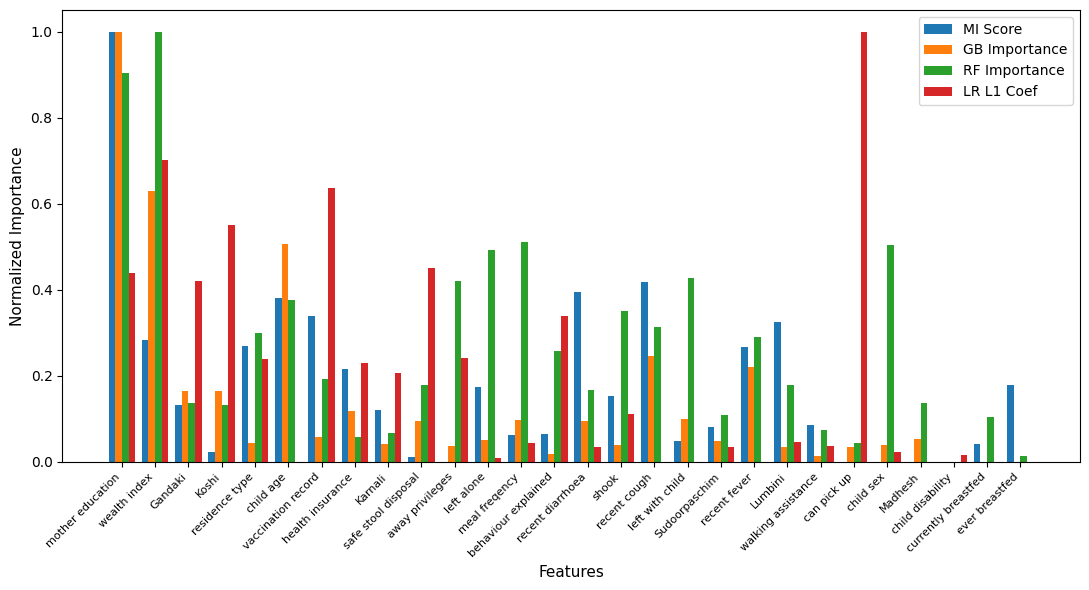

In [ ]:
# ============================================
# VISUALIZATION 1: FEATURE IMPORTANCE
# ============================================

print("\n" + "="*60)
print("CREATING FEATURE IMPORTANCE PLOT")
print("="*60)

fig1, ax1 = plt.subplots(figsize=(11, 6))

top_15 = feature_scores_sorted
methods = ['MI_Score', 'GB_Importance', 'RF_Importance', 'LR_L1_Coef']
x = np.arange(len(top_15))
width = 0.2

for i, method in enumerate(methods):
    scores_norm = (
        (top_15[method] - top_15[method].min()) /
        (top_15[method].max() - top_15[method].min() + 1e-10)
    )
    ax1.bar(x + i * width, scores_norm, width, label=method.replace('_', ' '))

ax1.set_xlabel('Features', fontsize=11)
ax1.set_ylabel('Normalized Importance', fontsize=11)
# ax1.set_title('Features importance by different methods', fontsize=12)
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(top_15['Feature'], rotation=45, ha='right', fontsize=8)
ax1.legend()
# ax1.grid(axis='y', alpha=0.3)
plt.savefig("/workspaces/malnutrition/Plots/features_by_methods.png", dpi=300)

plt.tight_layout()
plt.show()


In [15]:
# ============================================
# VISUALIZATION 2: PERFORMANCE vs FEATURE COUNT
# ============================================

# print("\n" + "="*60)
# print("CREATING PERFORMANCE PLOT")
# print("="*60)

# fig2, ax2 = plt.subplots(figsize=(7, 5))

# top_k_perf = performance_df[performance_df['Strategy'].str.contains('Top')]

# if len(top_k_perf) > 0:
#     ax2.plot(
#         top_k_perf['K'],
#         top_k_perf['CV_F1_Mean'],
#         marker='o',
#         linewidth=2,
#         markersize=8
#     )
#     ax2.fill_between(
#         top_k_perf['K'],
#         top_k_perf['CV_F1_Mean'] - top_k_perf['CV_F1_Std'],
#         top_k_perf['CV_F1_Mean'] + top_k_perf['CV_F1_Std'],
#         alpha=0.3
#     )

# ax2.set_xlabel('Number of Features', fontsize=10)
# ax2.set_ylabel('F1-Score (Cross-Validation)', fontsize=10)
# ax2.set_title('Model Performance vs Feature Count', fontsize=12)
# # ax2.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()


In [16]:
# Print the actual top 10 features
print("\n" + "="*60)
print("FINAL RECOMMENDATION: TOP 17 FEATURES")
print("="*60)

top_10_final = feature_scores_sorted.head(17)
print("\nFeature | Avg Rank | Boruta Status | MI Score | GB Importance")
print("-" * 80)
for idx, row in top_10_final.iterrows():
    print(f"{row['Feature']:30s} | {row['Average_Rank']:6.2f} | "
          f"{row['Boruta_Status']:12s} | {row['MI_Score']:8.4f} | "
          f"{row['GB_Importance']:8.4f}")

# Verify performance with exactly these 10
X_final = X_train[top_10_final['Feature'].tolist()]
scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final)

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

gb_final = GradientBoostingClassifier(n_estimators=100, random_state=42)
cv_final = cross_val_score(gb_final, X_final_scaled, y_train, cv=5, scoring='f1')

print(f"\nFinal Performance (Top 17 features):")
print(f"  F1-Score: {cv_final.mean():.4f} (±{cv_final.std():.4f})")
print(f"  Features: {', '.join(top_10_final['Feature'].tolist())}")


FINAL RECOMMENDATION: TOP 17 FEATURES

Feature | Avg Rank | Boruta Status | MI Score | GB Importance
--------------------------------------------------------------------------------
mother education               |   1.82 | Confirmed    |   0.0425 |   0.2430
wealth index                   |   2.55 | Confirmed    |   0.0121 |   0.1534
Gandaki                        |   6.09 | Confirmed    |   0.0056 |   0.0412
Koshi                          |   6.64 | Confirmed    |   0.0010 |   0.0416
residence type                 |   7.18 | Confirmed    |   0.0114 |   0.0122
child age                      |   7.45 | Confirmed    |   0.0162 |   0.1237
vaccination record             |   7.73 | Confirmed    |   0.0144 |   0.0158
health insurance               |   8.36 | Confirmed    |   0.0092 |   0.0301
Karnali                        |   8.55 | Confirmed    |   0.0051 |   0.0117
safe stool disposal            |   9.36 | Confirmed    |   0.0005 |   0.0248
away privileges                |  10.27 | Confi

Running Boruta feature selection...
Features: 28, Samples: 5872



Boruta selection completed!
Confirmed features: 18

BORUTA FEATURE SELECTION SUMMARY
            Feature  Rank  Confirmed  Tentative    Status
         left alone     1       True      False Confirmed
    left with child     1       True      False Confirmed
    away privileges     1       True      False Confirmed
behaviour explained     1       True      False Confirmed
              shook     1       True      False Confirmed
     residence type     1       True      False Confirmed
      meal freqency     1       True      False Confirmed
          child age     1       True      False Confirmed
   recent diarrhoea     1       True      False Confirmed
            Gandaki     1       True      False Confirmed
 vaccination record     1       True      False Confirmed
safe stool disposal     1       True      False Confirmed
       recent cough     1       True      False Confirmed
       wealth index     1       True      False Confirmed
   health insurance     1       True      Fa

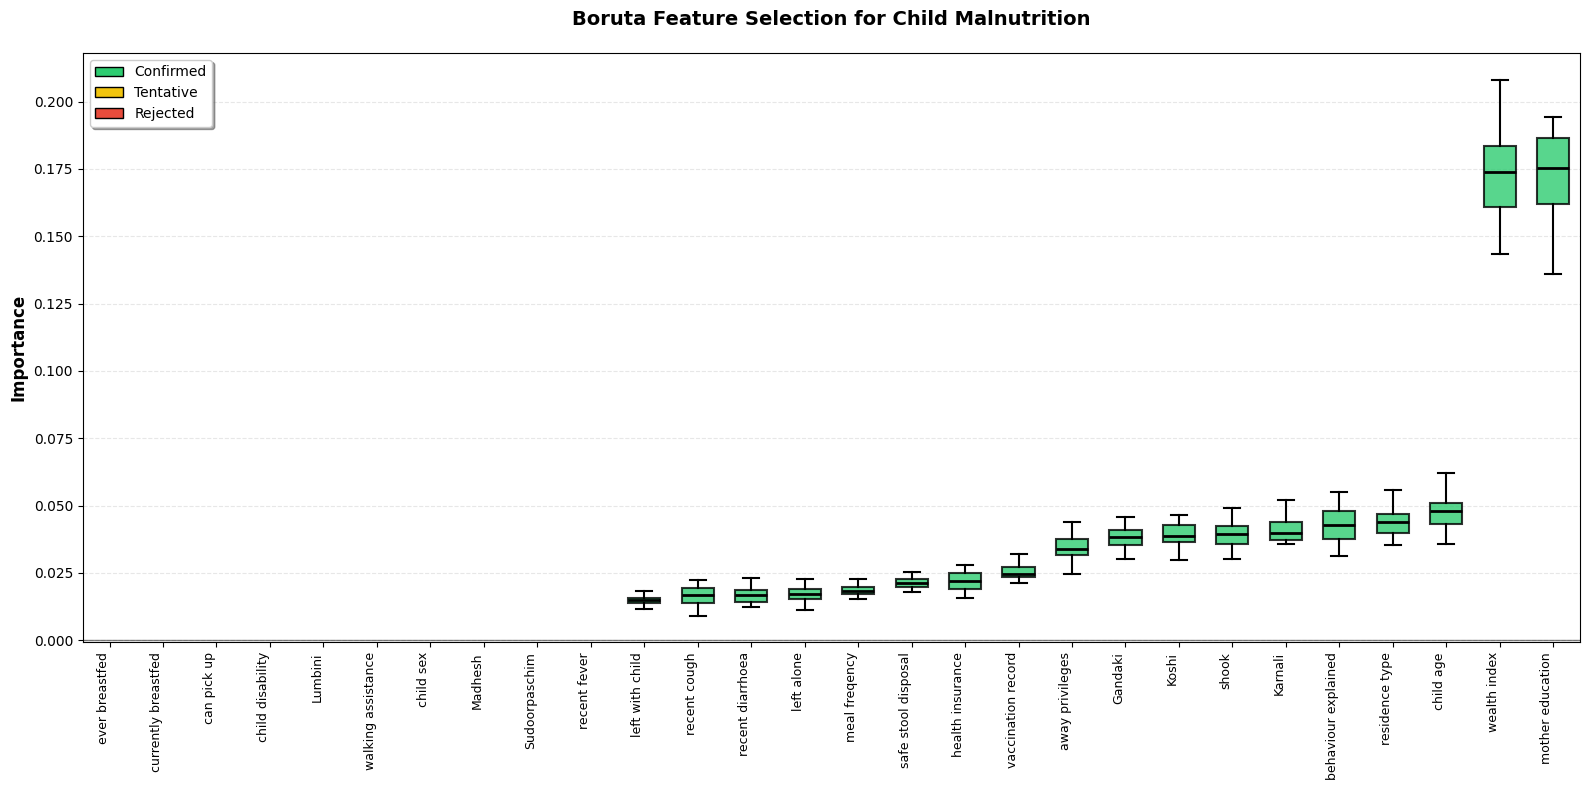

In [28]:
X_encoded = X_train.copy()

def create_boruta_boxplot(X_encoded, y_train, feature_names=None, max_depth=None, 
                          n_estimators='auto', max_iter=100, random_state=42,
                          figsize=(16, 8)):
    
    # Convert to numpy if DataFrame
    if isinstance(X_encoded, pd.DataFrame):
        feature_names = X_encoded.columns.tolist()
        X_np = X_encoded.values
    else:
        X_np = X_encoded
        if feature_names is None:
            feature_names = [f"Feature_{i}" for i in range(X_np.shape[1])]
    
    y_np = y_train.values if isinstance(y, pd.Series) else y_train
    
    print("Running Boruta feature selection...")
    print(f"Features: {X_np.shape[1]}, Samples: {X_np.shape[0]}")
    
    # Initialize Random Forest
    rf = RandomForestClassifier(
        n_jobs=-1,
        class_weight='balanced',
        max_depth=max_depth,
        random_state=random_state
    )
    
    # Initialize and fit Boruta
    boruta_selector = BorutaPy(
        estimator=rf,
        n_estimators=n_estimators,
        verbose=0,
        random_state=random_state,
        max_iter=max_iter
    )
    
    boruta_selector.fit(X_np, y_np)
    
    print("\nBoruta selection completed!")
    print(f"Confirmed features: {boruta_selector.n_features_}")
    
    # Get feature importance history
    importance_history = boruta_selector.importance_history_
    
    # Determine feature status
    confirmed = boruta_selector.support_
    tentative = boruta_selector.support_weak_
    rejected = ~(confirmed | tentative)
    
    # Create DataFrame for plotting
    plot_data = []
    for i, feature in enumerate(feature_names):
        importances = importance_history[:, i]
        
        if confirmed[i]:
            status = 'Confirmed'
            color = '#2ecc71'  # Green
        elif tentative[i]:
            status = 'Tentative'
            color = '#f1c40f'  # Yellow
        else:
            status = 'Rejected'
            color = '#e74c3c'  # Red
        
        for imp in importances:
            plot_data.append({
                'Feature': feature,
                'Importance': imp,
                'Status': status,
                'Color': color,
                'Rank': boruta_selector.ranking_[i]
            })
    
    df_plot = pd.DataFrame(plot_data)
    
    # Sort features by median importance
    feature_order = df_plot.groupby('Feature')['Importance'].median().sort_values().index
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create boxplot data
    positions = []
    box_data = []
    colors = []
    labels = []
    
    for pos, feature in enumerate(feature_order):
        feature_data = df_plot[df_plot['Feature'] == feature]
        box_data.append(feature_data['Importance'].values)
        positions.append(pos)
        colors.append(feature_data['Color'].iloc[0])
        labels.append(feature)
    
    # Create boxplot
    bp = ax.boxplot(box_data, positions=positions, widths=0.6,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(linewidth=1.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    medianprops=dict(linewidth=2, color='black'),
                    flierprops=dict(marker='o', markerfacecolor='white', 
                                   markersize=4, markeredgecolor='black',
                                   markeredgewidth=0.5))
    
    # Color boxes according to status
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    
    # Styling
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=9)
    ax.set_ylabel('Importance', fontweight='bold', fontsize=12)
    ax.set_title('Boruta Feature Selection for Child Malnutrition', 
                 fontweight='bold', fontsize=14, pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)
    
    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', edgecolor='black', label='Confirmed'),
        Patch(facecolor='#f1c40f', edgecolor='black', label='Tentative'),
        Patch(facecolor='#e74c3c', edgecolor='black', label='Rejected')
    ]
    ax.legend(handles=legend_elements, loc='upper left', 
             frameon=True, shadow=True, fontsize=10)
    
    # Add counts to legend
    n_confirmed = confirmed.sum()
    n_tentative = tentative.sum()
    n_rejected = rejected.sum()
    
    text_str = f'Confirmed: {n_confirmed}\nTentative: {n_tentative}\nRejected: {n_rejected}'
    ax.text(0.02, 0.98, text_str, transform=ax.transAxes,
           verticalalignment='top', bbox=dict(boxstyle='round', 
           facecolor='wheat', alpha=0.5), fontsize=9)
    
    plt.tight_layout()
    
    fig.savefig(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Rework\Plots\boruta.png", dpi=300, bbox_inches='tight')
    
    return fig, boruta_selector


def create_boruta_summary_table(boruta_selector, feature_names):
    """
    Create a summary table of Boruta results.
    """
    results = pd.DataFrame({
        'Feature': feature_names,
        'Rank': boruta_selector.ranking_,
        'Confirmed': boruta_selector.support_,
        'Tentative': boruta_selector.support_weak_,
        'Status': ['Confirmed' if boruta_selector.support_[i] 
                   else 'Tentative' if boruta_selector.support_weak_[i]
                   else 'Rejected' for i in range(len(feature_names))]
    })
    
    results = results.sort_values('Rank')
    
    print("\n" + "="*70)
    print("BORUTA FEATURE SELECTION SUMMARY")
    print("="*70)
    print(results.to_string(index=False))
    print("="*70)
    print(f"\nTotal Features: {len(feature_names)}")
    print(f"Confirmed: {boruta_selector.support_.sum()}")
    print(f"Tentative: {boruta_selector.support_weak_.sum()}")
    print(f"Rejected: {(~(boruta_selector.support_ | boruta_selector.support_weak_)).sum()}")
    
    return results


def plot_boruta_feature_importance_comparison(boruta_selector, feature_names, 
                                              n_top=20, figsize=(10, 8)):
    """
    Create a horizontal bar plot comparing confirmed vs rejected features.
    """
    # Get median importance for each feature
    # importance_history = boruta_selector.importance_history_
    importance_history = boruta_selector.importance_history_
    if importance_history.shape[1] != len(feature_names):
        raise ValueError("Mismatch between importance history and feature names")

    median_importance = np.median(importance_history, axis=0)
    
    # Create DataFrame
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Median_Importance': median_importance,
        'Status': ['Confirmed' if boruta_selector.support_[i] 
                   else 'Tentative' if boruta_selector.support_weak_[i]
                   else 'Rejected' for i in range(len(feature_names))],
        'Rank': boruta_selector.ranking_
    })
    
    # Sort by importance
    df_importance = df_importance.sort_values('Median_Importance', ascending=False)
    
    # Take top N
    df_top = df_importance.head(n_top)
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color mapping
    color_map = {'Confirmed': '#2ecc71', 'Tentative': '#f1c40f', 'Rejected': '#e74c3c'}
    colors = [color_map[status] for status in df_top['Status']]
    
    # Horizontal bar plot
    y_pos = np.arange(len(df_top))
    ax.barh(y_pos, df_top['Median_Importance'], color=colors, 
            edgecolor='black', linewidth=1)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_top['Feature'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Median Feature Importance', fontweight='bold', fontsize=11)
    ax.set_title(f'Top {n_top} Features by Boruta Importance', 
                 fontweight='bold', fontsize=13, pad=15)
    ax.grid(axis='x', alpha=0.3)
    
    # Add legend
    legend_elements = [
        Patch(facecolor='#2ecc71', edgecolor='black', label='Confirmed'),
        Patch(facecolor='#f1c40f', edgecolor='black', label='Tentative'),
        Patch(facecolor='#e74c3c', edgecolor='black', label='Rejected')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, shadow=True)
    
    plt.tight_layout()
    return fig

# Bourta Visualizations and Summary
# 1. Create main Boruta boxplot
fig, boruta_selector = create_boruta_boxplot(
    X_encoded, 
    y_train, 
    max_depth=5,
    max_iter=100,
    random_state=42,
    figsize=(16, 8)
)
fig.savefig(r"/workspaces/malnutrition/Plots/boruta.png", dpi=600, bbox_inches="tight")
# 2. Create summary table
results_table = create_boruta_summary_table(boruta_selector, X_encoded.columns)

plt.show()

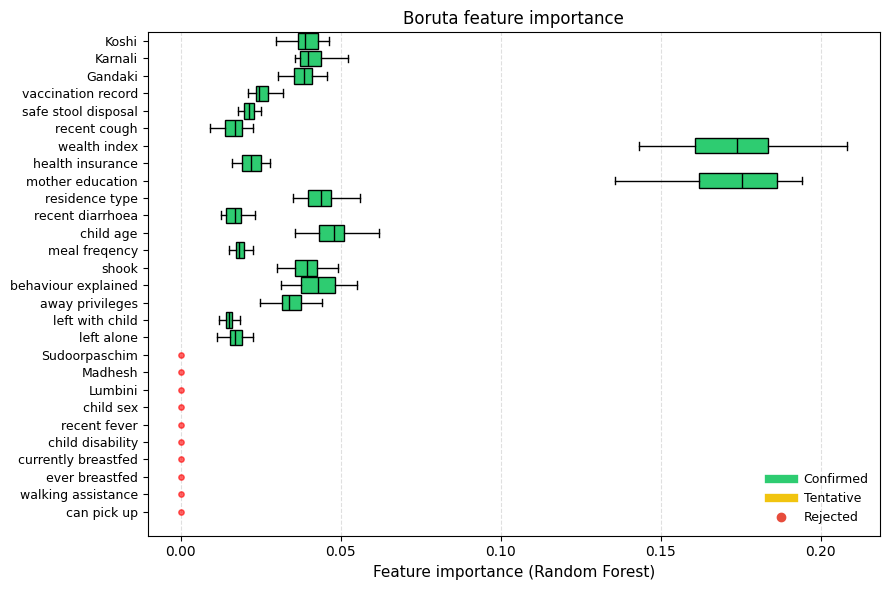

In [26]:
def plot_boruta_nature_style(boruta_selector, feature_names, figsize=(11, 6)):

    importance = boruta_selector.importance_history_
    confirmed = boruta_selector.support_
    tentative = boruta_selector.support_weak_
    rejected = ~(confirmed | tentative)

    # Build dataframe
    df = pd.DataFrame(importance, columns=feature_names).melt(var_name='Feature', value_name='Importance')

    df['Status'] = df['Feature'].map({
        f: 'Confirmed' if confirmed[i]
        else 'Tentative' if tentative[i]
        else 'Rejected'
        for i, f in enumerate(feature_names)
    })

    # Sort by median importance
    order = (df.groupby('Feature')['Importance'].median().sort_values().index)

    fig, ax = plt.subplots(figsize=figsize)

    # --- Confirmed ---
    confirmed_data = [
        importance[:, i]
        for i, f in enumerate(feature_names)
        if confirmed[i]
    ]
    confirmed_labels = [
        f for i, f in enumerate(feature_names) if confirmed[i]
    ]

    # --- Tentative ---
    tentative_data = [
        importance[:, i]
        for i, f in enumerate(feature_names)
        if tentative[i]
    ]
    tentative_labels = [
        f for i, f in enumerate(feature_names) if tentative[i]
    ]

    # --- Rejected ---
    rejected_labels = [
        f for i, f in enumerate(feature_names) if rejected[i]
    ]

    y_pos = 0

    # Plot rejected (zero line)
    ax.scatter(np.zeros(len(rejected_labels)), np.arange(y_pos, y_pos + len(rejected_labels)), color='red', s=15, alpha=0.6, label='Rejected')
    y_pos += len(rejected_labels)

    # Plot tentative
    if len(tentative_data) > 0:
        ax.boxplot(
            tentative_data,
            vert=False,
            positions=np.arange(y_pos, y_pos + len(tentative_data)),
            widths=0.9,
            patch_artist=True,
            boxprops=dict(facecolor='#f1c40f', edgecolor='black'),
            medianprops=dict(color='black'),
            showfliers=False
        )
        y_pos += len(tentative_data)

    # Plot confirmed
    if len(confirmed_data) > 0:
        ax.boxplot(
            confirmed_data,
            vert=False,
            positions=np.arange(y_pos, y_pos + len(confirmed_data)),
            widths=0.9,
            patch_artist=True,
            boxprops=dict(facecolor='#2ecc71', edgecolor='black'),
            medianprops=dict(color='black'),
            showfliers=False
        )
        y_pos += len(confirmed_data)


    # Y-axis labels
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(
        rejected_labels + tentative_labels + confirmed_labels,
        fontsize=9
    )

    ax.set_xlabel("Feature importance (Random Forest)", fontsize=11)
    ax.set_title("Boruta feature importance", fontsize=12)

    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    # Minimal legend
    ax.legend(
        handles=[
            plt.Line2D([0], [0], color='#2ecc71', lw=6, label='Confirmed'),
            plt.Line2D([0], [0], color='#f1c40f', lw=6, label='Tentative'),
            plt.Line2D([0], [0], marker='o', color='#e74c3c', lw=0, label='Rejected')
        ],
        frameon=False,
        fontsize=9,
        loc='lower right'
    )

    plt.tight_layout()
    return fig

fig = plot_boruta_nature_style(boruta_selector, X_encoded.columns, figsize=(9, 6))
fig.savefig(r"/workspaces/malnutrition/Plots/boruta_feature.png", dpi=600, bbox_inches="tight")

“Boruta feature selection was performed using a Random Forest classifier.
Confirmed and tentative features are shown as distributions of importance values across iterations, while rejected features—whose importance remained zero—are represented as point estimates at zero.”

## Visualization

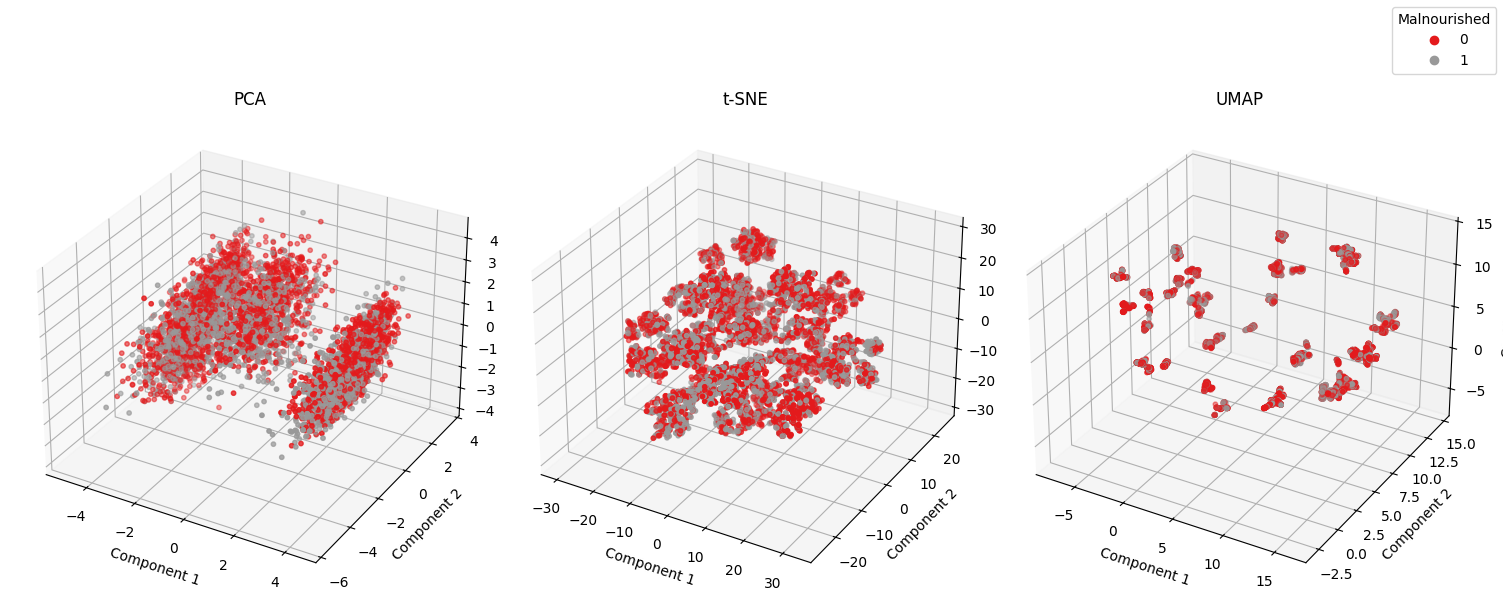

In [22]:
# Encode and scale the dataset
X = pd.get_dummies(df_final.drop(columns='malnutrition'), drop_first=True)
y = df_final['malnutrition']
X_scaled = StandardScaler().fit_transform(X)

# Reduce with PCA (3D)
X_pca = PCA(n_components=3).fit_transform(X_scaled)

# Reduce with t-SNE (3D)
X_tsne = TSNE(n_components=3, random_state=42).fit_transform(X_scaled)

# Reduce with UMAP (3D)
X_umap = umap.UMAP(n_components=3, random_state=42).fit_transform(X_scaled)

# Plot
fig = plt.figure(figsize=(15, 7))

# PCA
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, cmap='Set1', s=10)
ax1.set_title("PCA")
ax1.set_xlabel("Component 1")
ax1.set_ylabel("Component 2")
ax1.set_zlabel("Component 3")

# t-SNE
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=y, cmap='Set1', s=10)
ax2.set_title("t-SNE")
ax2.set_xlabel("Component 1")
ax2.set_ylabel("Component 2")
ax2.set_zlabel("Component 3")

# UMAP
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=y, cmap='Set1', s=10)
ax3.set_title("UMAP")
ax3.set_xlabel("Component 1")
ax3.set_ylabel("Component 2")
ax3.set_zlabel("Component 3")

# Legend (common)
fig.legend(*scatter1.legend_elements(), title="Malnourished", loc="upper right")
# fig.suptitle("3D PCA vs t-SNE vs UMAP Projection of Dataset", fontsize=16)
plt.tight_layout()
plt.savefig(r"\Plots\data_separability.png", dpi = 300)
plt.show()

## Descriptive Statistics

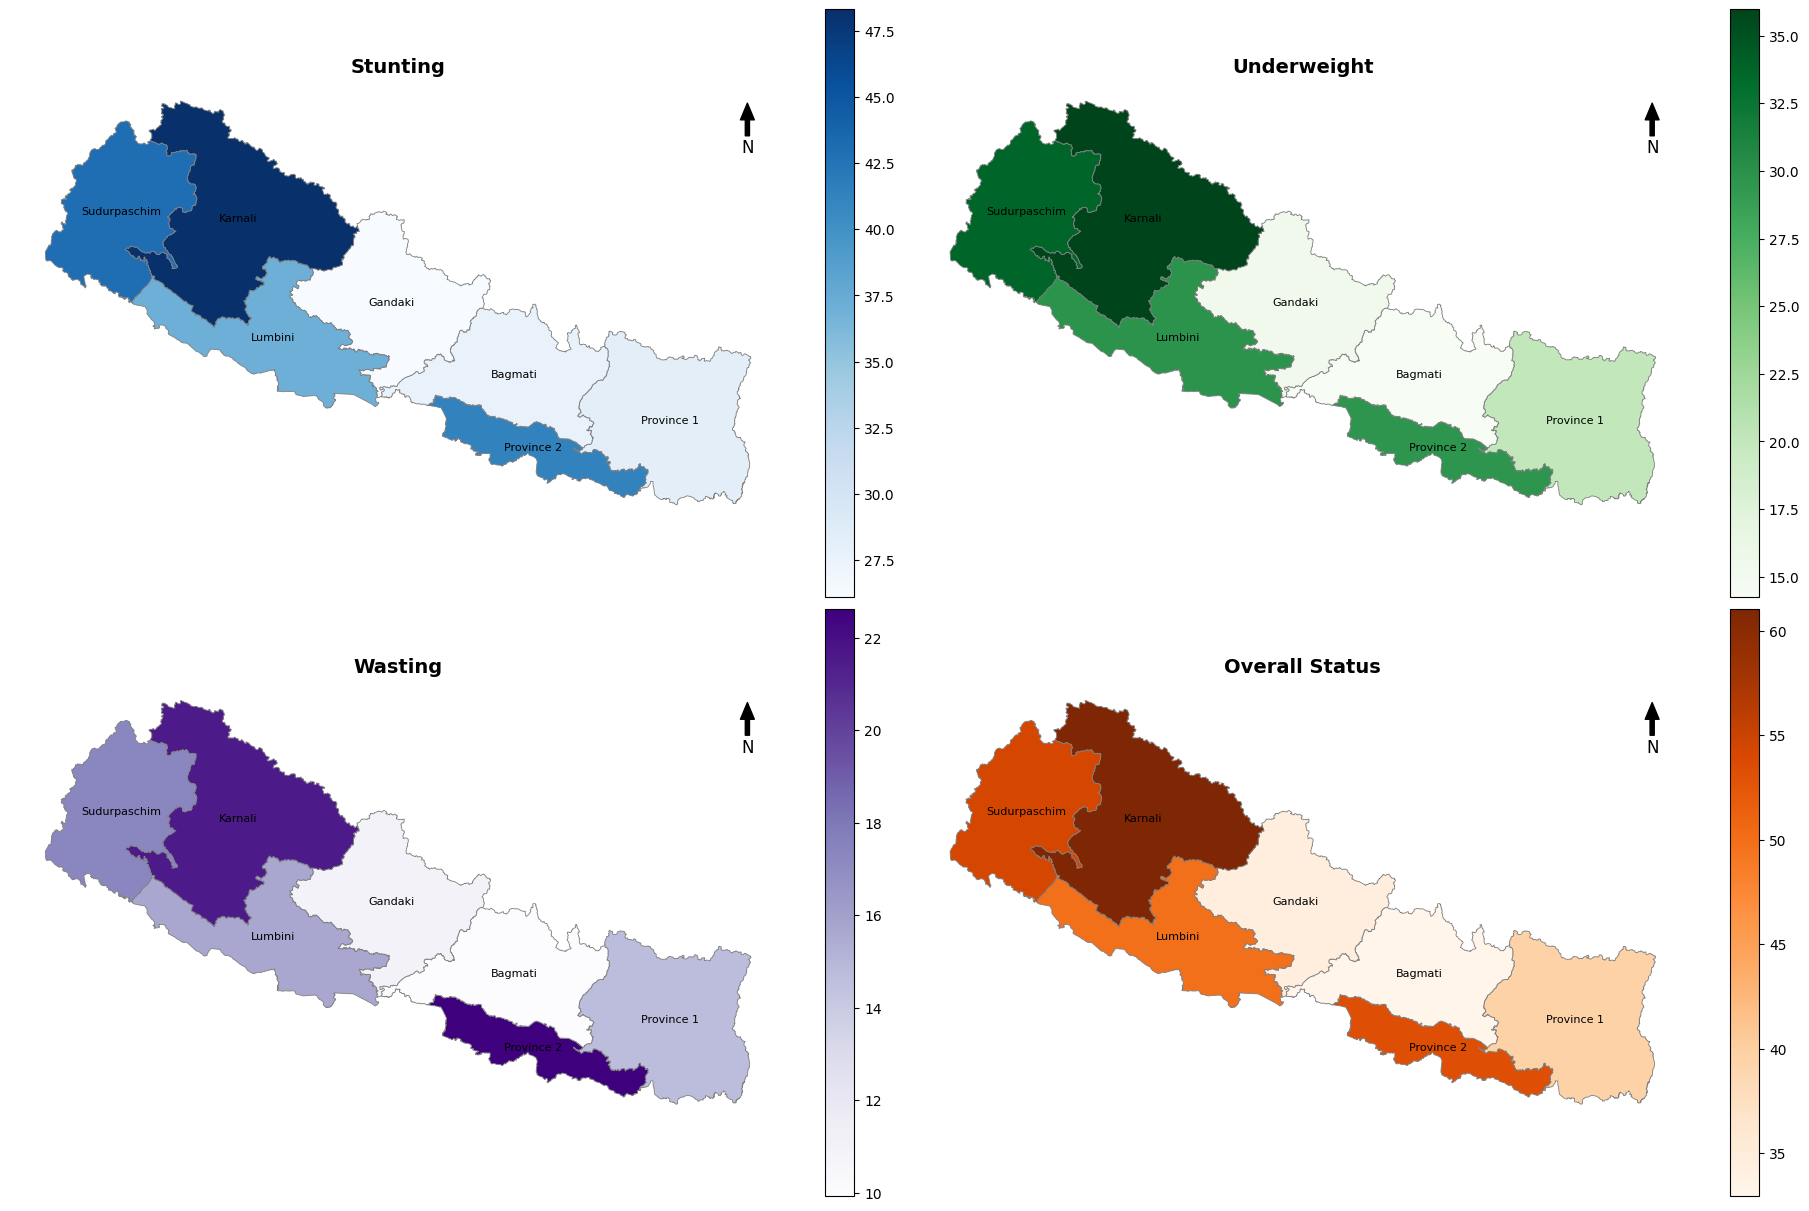

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load GeoJSON and prepare data
# gdf = gpd.read_file(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS_Rework\Dataset\nepal_admin1.geojson")  # name of downloaded file
# gdf = gpd.read_file(r"/workspaces/malnutrition/Dataset/nepal_admin1.geojson")  # name of downloaded file
gdf = gpd.read_file(r"/workspaces/malnutrition/Dataset/geoBoundaries-NPL-ADM1.geojson")

# gdf = gdf.rename(columns={"name": "province"})
gdf = gdf.rename(columns={"shapeName": "province"})

# Step 2: Your data
data = {
    'province': ['Province 1', 'Province 2', 'Bagmati', 'Gandaki',
                 'Lumbini', 'Karnali', 'Sudurpaschim'],
    'Stunting': [28.39, 41.34, 27.69, 26.11, 37.09, 48.31, 42.94],
    'Underweight': [20.08, 29.61, 14.26, 15.42, 29.85, 35.97, 33.69],
    'Wasting': [14.72, 22.63, 9.92, 10.97, 15.68, 21.56, 17.32],
    'Status': [39.64, 53.35, 32.94, 34.58, 49.75, 61.04, 54.33]
}
df_data = pd.DataFrame(data)

# Step 3: Merge with geodata
merged = gdf.merge(df_data, on='province')

# Step 4: Create 2x2 plot grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

cols = ['Stunting', 'Underweight', 'Wasting', 'Status']
cmaps = ['Blues', 'Greens', 'Purples', 'Oranges']
titles = ['Stunting', 'Underweight', 'Wasting', 'Overall Status']

# Flatten the axes for easy iteration
axes = axes.flatten()

for ax, col, cmap, title in zip(axes, cols, cmaps, titles):
    merged.plot(
        column=col, cmap=cmap, linewidth=0.6,
        edgecolor='gray', legend=True, ax=ax
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

    # -------------------------
    # North arrow (compass)
    # -------------------------
    ax.annotate(
        'N',
        xy=(0.95, 0.95),
        xytext=(0.95, 0.85),
        arrowprops=dict(facecolor='black', width=3, headwidth=10),
        ha='center',
        va='center',
        fontsize=12,
        xycoords=ax.transAxes
    )

# Step 5: Add province names at centroids
for idx, row in merged.iterrows():
    centroid = row['geometry'].centroid
    for ax in axes:
        ax.text(centroid.x, centroid.y, row['province'], fontsize=8,
                ha='center', va='center', color='black')
plt.savefig(r"/workspaces/malnutrition/Plots/spatial_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

In [11]:
print(gdf.columns)

Index(['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType',
       'geometry'],
      dtype='str')


In [16]:
# Contingency table for categorical features
for col in df_final.columns:
    table = pd.crosstab(df_final[col], df_final['malnutrition'], margins=False)

    # Calculate row-wise percentages
    row_pct = table.div(table.sum(axis=1), axis=0) * 100
    row_pct = row_pct.round(1)  # Round to 1 decimal

    # Combine count and percentage for pretty output
    combined = table.astype(str) + " (" + row_pct.astype(str) + ")"

    print(f"\nContingency table for {col}:\n{combined}\n")


Contingency table for left alone:
malnutrition            0            1
left alone                            
-1.0            19 (45.2)    23 (54.8)
 0.0          2945 (58.7)  2075 (41.3)
 1.0            81 (52.3)    74 (47.7)
 2.0           141 (55.7)   112 (44.3)
 3.0            71 (52.2)    65 (47.8)
 4.0            68 (58.6)    48 (41.4)
 5.0            46 (41.4)    65 (58.6)
 6.0            33 (57.9)    24 (42.1)
 7.0           267 (50.8)   259 (49.2)


Contingency table for left with child:
malnutrition               0            1
left with child                          
-1.0               15 (38.5)    24 (61.5)
 0.0             3101 (58.5)  2201 (41.5)
 1.0              116 (57.1)    87 (42.9)
 2.0              140 (54.7)   116 (45.3)
 3.0               50 (37.6)    83 (62.4)
 4.0               39 (51.3)    37 (48.7)
 5.0               55 (52.9)    49 (47.1)
 6.0               14 (41.2)    20 (58.8)
 7.0              141 (52.4)   128 (47.6)


Contingency table for can pick 